## Start modelering van voorspellingsmodel

### Import data

In [ ]:
import pandas as pd
import category_encoders as ce
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn import metrics

df = pd.read_csv("../../csv/new_train_data/train_CarBreakDown.csv")

# Split method

# df_safe = df[df['breakdown_next_30_days'] == 0]
# df_breakdown = df[df['breakdown_next_30_days'] == 1]

### Splits data in x en y en in train en test data

In [ ]:
used_features =['vehicle_brand','vehicle_age_years','km_per_engine_hour','service_ratio','oil_quality_pct','avg_trip_length_km','weather_exposure','fuel_type','cleanliness_score','driver_satisfaction_score','tyre_type']

x = df[used_features]
y = df[['breakdown_next_30_days']]

# Split method

# x_safe = df_safe[used_features]
# x_breakdown = df_breakdown[used_features]
# y_safe = df_safe[['breakdown_next_30_days']]
# y_breakdown = df_breakdown[['breakdown_next_30_days']]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)


In [ ]:
x

,vehicle_brand,vehicle_age_years,km_per_engine_hour,service_ratio,oil_quality_pct,avg_trip_length_km,weather_exposure,fuel_type,cleanliness_score,driver_satisfaction_score,tyre_type
0,Hyundai,1.0,28.227486,0.062189,25.491428,41.692205,medium,hybrid,47.223966,5.842726,winter
1,Toyota,5.0,31.067768,0.019883,54.060416,6.464345,high,diesel,72.246829,4.719607,winter
2,Renault,1.0,29.259912,0.016840,52.147399,1.458703,high,hybrid,57.117174,7.676373,summer
3,Volvo,11.0,46.297794,0.077518,52.388355,29.987997,medium,diesel,34.610147,4.221209,summer
4,Ford,2.0,29.597029,0.022871,48.387331,21.020533,low,diesel,86.677049,6.622987,summer
...,...,...,...,...,...,...,...,...,...,...,...
716,Toyota,7.0,27.001306,0.009470,53.181356,12.044847,low,petrol,74.254700,7.883355,summer
717,Ford,6.0,27.256494,0.192828,72.835609,43.227761,high,diesel,73.314438,9.001056,summer
718,Toyota,9.0,30.977275,0.184187,69.923976,1.773332,medium,petrol,62.945838,5.346505,summer
719,Ford,19.0,31.918450,0.087473,60.566073,39.444093,low,diesel,88.354147,5.944547,winter


In [ ]:
y

,breakdown_next_30_days
0,0
1,0
2,0
3,0
4,0
...,...
716,0
717,0
718,1
719,0


### Encoding van categorische velden

In [ ]:
# !pip install --upgrade category_encoders

category_encoder = ce.OrdinalEncoder(cols = ['vehicle_brand','weather_exposure','fuel_type','tyre_type'])

x_encoded = category_encoder.fit_transform(x_train)

# Split method

# x_safe_encoded = category_encoder.fit_transform(x_safe)
# x_breakdown_encoded = category_encoder.transform(x_breakdown)
x_test_encoded = category_encoder.transform(x_test)
x_encoded

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
x_encoded, y_train = smote.fit_resample(x_encoded, y_train)

### Train model via Random forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from random import randint

# Split method

# end_df = pd.DataFrame([])
# end_df = pd.concat([end_df, x_breakdown_encoded])
# end_df = pd.concat([end_df, x_safe_encoded.sample(n=x_breakdown_encoded.shape[0])])

clf = RandomForestClassifier(criterion='entropy',n_estimators=100, max_samples = 50, class_weight="balanced")
clf = clf.fit(x_encoded, y_train.values.ravel()) # values.ravel() because a warning appears about using a 1d array so we need to flatten it.




from xgboost import XGBClassifier
# create model
model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=6,
    random_state=42
)

# train
model.fit(x_encoded, y_train)

# Split method

# use end_df and .sample(n=x_breakdown_encoded.shape[0]*2) instead for the fit



# proba = model.predict_proba(x_test_encoded)[:,0]

# pred = (proba > 0.95).astype(int)
# pred

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

#### Voorspelling output

In [ ]:
clf_prediction = clf.predict(x_test_encoded)
print(clf_prediction)

[0 0 1 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 1 0 0 0 1 0 0 0 0 1 0 1 1 0 1 1 1
 1 0 0 1 0 0 0 0 0 0 0 0 1 0 1 0 1 1 1 0 1 0 0 0 1 0 0 1 1 1 1 1 0 0 0 1 0
 0 0 0 0 0 0 1 0 0 1 0 1 1 1 0 0 0 1 0 1 0 1 1 0 1 0 0 1 0 0 0 0 0 0 0 0 0
 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 1 1 0 0 0 0 0 1 1 1 1 1]


#### Accuracy weergave

In [ ]:
print(f"Accuracy: {metrics.accuracy_score(y_test, clf_prediction)}")

Accuracy: 0.6275862068965518


#### Confusion matrix

In [ ]:
confusion_matrix(y_test, clf_prediction)

array([[83, 41],
       [13,  8]])

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, x_encoded, y_train, cv=5, scoring="f1")
print("Mean F1:", scores.mean())

Mean F1: 0.8497848655798073


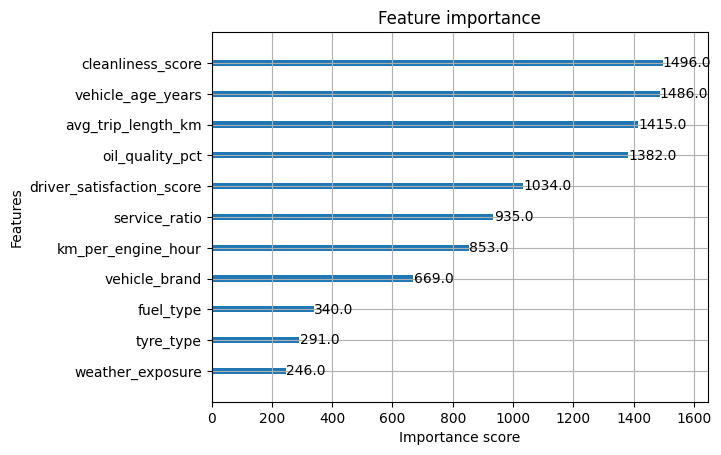

In [ ]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plot_importance(model)
plt.show()

## Spliting the break down and safe results

One of the problems in the dataset was that there is a considarably high amount of non breaking cars. To try and solve this we split the data in two data frames (see # split method), one with only working cars and one with all the cars that brokedown. Then when fitting the model we took a sample of 100 from both then dataframes and combined them to form the train data. This had little effect on the end result with the accurasy and false positives not changing.

In addition we also tried to use duplicate rows of the breakdwon dataframe to see if the problem was the lack of data but this also dit not change it.

## changing prediction certainty treshholds
proba = clf.predict_proba(x_test_encoded)[:,0]

pred = (proba > 0.81).astype(int)

pred

This code makes a model which requires predictions to be of a certain certainty. This solved the issue of always guessing 0 but also tanked the accuracy.